In [1]:
import pprint
import csv
import os
import torch
from PIL import Image
from torchvision.transforms import transforms
import torch.nn.functional as F
import warnings
from urllib3.exceptions import InsecureRequestWarning
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from model import EmotionClassifier
from variables import *

warnings.simplefilter("ignore", InsecureRequestWarning)


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {device}")
print(f"Running {experiment_name} experiment")
pprint.pp(configuration)

model = EmotionClassifier().to(device)
model.load_state_dict(
    torch.load(f"{output_path}/{experiment_name}/model.pth", map_location=device)
)
model.eval()

Using device: mps
Running class_weights_ADAMW experiment
{'apply_class_weight': True,
 'optimizer': 'adam_optimizer',
 'dataset': 'GiMeFive',
 'hyperparameters': {'num_epochs': 80,
                     'batch_size': 16,
                     'learning_rate': 0.001,
                     'weight_decay': 0.0001}}


/var/folders/7v/r5yp07196sx_fx1lqtntzf4m0000gn/T/ipykernel_83288/1987542901.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f"outputs/{experiment_name}/model

EmotionClassifier(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=1024, out_features=2048, bias=True)
  (fc2): Linear(in_features

In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def classify_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(image)
        probabilities = F.softmax(outputs, dim=1)
    scores = probabilities.cpu().numpy().flatten()
    rounded_scores = [round(score, 2) for score in scores]
    return rounded_scores


def process_folder(folder_path):
    results = []
    for img_filename in os.listdir(folder_path):
        if img_filename.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(folder_path, img_filename)
            scores = classify_image(img_path)
            results.append([img_path] + scores)
    return results

In [3]:
results = process_folder(dataset["validation"]["images"])
header = [
    "filepath",
    "happiness",
    "surprise",
    "sadness",
    "anger",
    "disgust",
    "fear",
]
with open(
    f"{output_path}/{experiment_name}/validation_classification_scores.csv", "w", newline=""
) as file:
    writer = csv.writer(file)
    writer.writerow(header)
    writer.writerows(results)

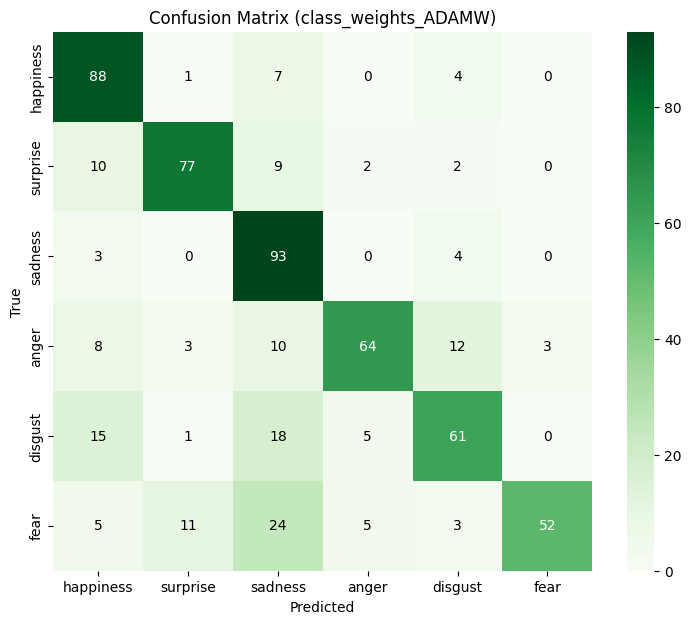

In [4]:
file_name = f"{output_path}/{experiment_name}/confusion_matrix.png"
scores_file = f"{output_path}/{experiment_name}/validation_classification_scores.csv"


df = pd.read_csv(scores_file)
class_names = ["happiness", "surprise", "sadness", "anger", "disgust", "fear"]
df["true"] = df["filepath"].apply(lambda x: x.split("_")[1].split(".")[0])
df["predicted"] = df[class_names].idxmax(axis=1)

confusion_matrix = pd.crosstab(
    df["true"], df["predicted"], rownames=["True"], colnames=["Predicted"]
)
confusion_matrix = confusion_matrix.reindex(
    index=class_names, columns=class_names, fill_value=0
)

plt.figure(figsize=(9, 7))
ax = sns.heatmap(
    confusion_matrix, fmt="d", cmap="Greens", square=True, cbar=True, annot_kws=None
)  # cmap= PiYG, Blues, BuPu, Greens, Oranges, YlGnBu, coolwarm
for i, row in enumerate(confusion_matrix.values):
    for j, val in enumerate(row):
        text_color = "white" if i == j else "black"
        ax.text(j + 0.5, i + 0.5, val, color=text_color, ha="center", va="center")
plt.title(f"Confusion Matrix ({experiment_name})")
plt.savefig(file_name, dpi=400, bbox_inches="tight", pad_inches=0.1)
plt.show()